# Background evolution of the field

In this notebook we construct the numerical background evolution of an axion field $\chi_0$ and plot it versus redshift $z$. The equation of motion for this field is $$ \chi_0''+2\mathcal{H}\chi_0'+a(\tau)^2\frac{dV}{d\chi_0}=0\, , $$ where $'=\frac{d}{d\tau}$ and $\mathcal{H}$ is the Hubble ratio in conformal time.

As always we started by importing the necessary libraries: *NumPy* for the computations and mathematical symbols, *ScyPy* for the integrations and the differential equations and *Matplotlib* for the plots.

In [22]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

First of all, we defined the different constants that will be used in the computations. The values are the fiducial values of the flat $\Lambda CDM$ model.

In [23]:
Omegam=0.3153
Omegar=9.04e-5
OmegaL=0.6847
Omegak=0.0
H0=1.4e-33 # in eV
Mpl=1.22e28 # in eV
mpl=Mpl/np.sqrt(8*np.pi)

Then we wrote two functions for $H(a)$ and $\frac{da}{d\tau}$. The first to explicit the dependece of $H$ on $a(\tau)$ and the cosmological parameters. The second to find, through a numerical integration, the final value of $\tau$ that will be necessary to solve numerically the differential equation in the next line. The solution will be the function $a(\tau)$. Last, we computed the derivative of the potential $$V(\chi_0)=m_\chi ^2 M_{pl}^2 \left[1-\cos\left(\frac{\chi_0}{M_{pl}}\right)\right]^2\, .$$ These three functions ($H(a)$, $a(\tau)$ and $\frac{dV}{d\chi_0})$ will be necessary to find the solution of the EOM.

In [24]:
def V(x0, mx):
    return Mpl**2*mx**2*(1-np.cos(x0/Mpl))**2
def H(a):
    return H0*np.sqrt(Omegar*a**(-4)+Omegam*a**(-3)+Omegak*a**(-2)+OmegaL)
def dadt(t, a):
    return a**2*H(a)

tau_fin=sp.integrate.quad(lambda a:1./(a**2*H(a)), 1e-8, 1)[0]
a_ini=1e-8
a_tau=sp.integrate.solve_ivp(dadt, (0, tau_fin), [a_ini], dense_output=True)

def Vp(x0, mx):
    return 2*Mpl*mx**2*np.sin(x0/Mpl)*(1-np.cos(x0/Mpl))

Setting up the last few items for the plot and the calculation. We want to compute the evolution for different values of $m_\chi$, in this case they are $m_\chi\simeq10^{-32},\, 10^{-31},\, 10^{-30},\, 10^{-29},\, 10^{-28}\, \text{and}\, 10^{-27}\, \text{eV}$. To do so we create an array of these values of $m_\chi$ and then we write this small function to just plot them better later.

In [25]:
mx_values=np.logspace(-32, -27, 6)
def LaTex_mass(mx):
    exp=int(np.log10(mx))
    return rf'10^{{{exp}}}'

colors=['b', 'g', 'r', 'c', 'm', 'y']

We start now by defining the EOM by splitting it in a system of two first order differential equations.

In [26]:
def eom(tau, y, mx):
    x0, vx=y
    a=np.interp(tau, a_tau.t, a_tau.y[0])
    return [vx, -2*a*H(a)*vx-a**2*Vp(x0, mx)]

Solving the EOM for the different values of $m_\chi$ using as initial conditions $(\chi_0^{ini},\, v_\chi)=(m_{Pl},\, 0)$ by taking the $[0]$ element of *solution*. Later we divide it by the initial condition in order to obtain the ratio of the field with respect to the initial state. To show all of this we plot everything in a logarithmic scale as a function of redshift.

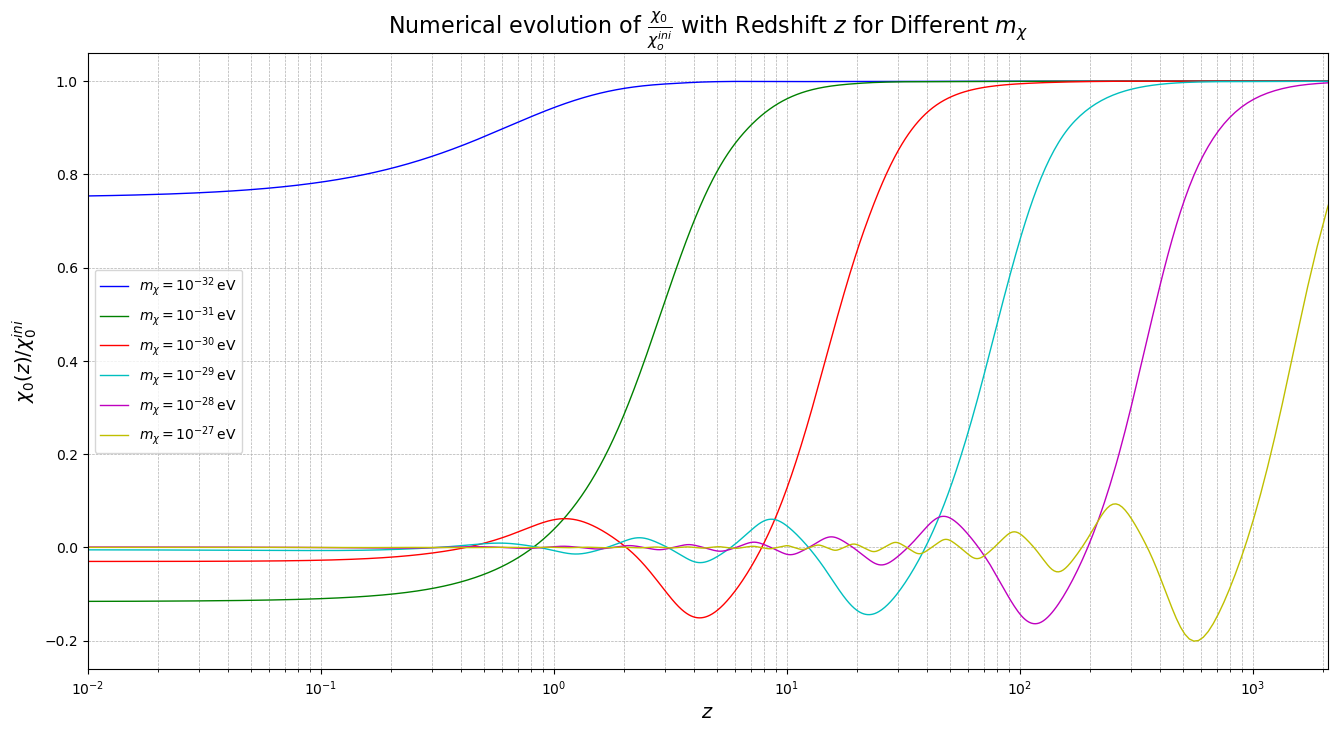

In [27]:
tau_grid=np.linspace(0, tau_fin, 1000)
plt.figure(figsize=(16, 8))

for mx, col in zip(mx_values, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (0,tau_fin), initial_conditions, args=(mx,), dense_output=True)
    
    chi_tau=solution.sol(tau_grid)[0]
    s=chi_tau/initial_conditions[0]
    z_values=1./a_tau.sol(tau_grid)[0]-1.
    plt.plot(z_values, s, color=col, label=rf'$m_\chi = {LaTex_mass(mx)}\, \mathrm{{eV}}$', linewidth=1)


plt.xscale('log')
plt.xticks([1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3])
plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 2100)
plt.ylabel(r'$\chi_0 (z)/ \chi_0^{ini}$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Numerical evolution of $\frac{\chi_0}{\chi_o^{ini}}$ with Redshift $z$ for Different $m_\chi$', fontsize=16)
plt.legend()
plt.show()

Moreover, it is possible to compute the value of $\omega_{\chi_0}$, i.e. the ratio of the equation of state of $\chi_0$. To do so we can simply take the second result given by the integration of the equation of motion, $\chi_0'(\tau)=v_{\chi_0}$, and using the formula $$ \omega_{\chi_0}=\frac{\chi_0'-2a^2V(\chi_0)}{\chi_0'+2a^2V(\chi_0)}\, ,$$ we get the evolution of omega in redshift.

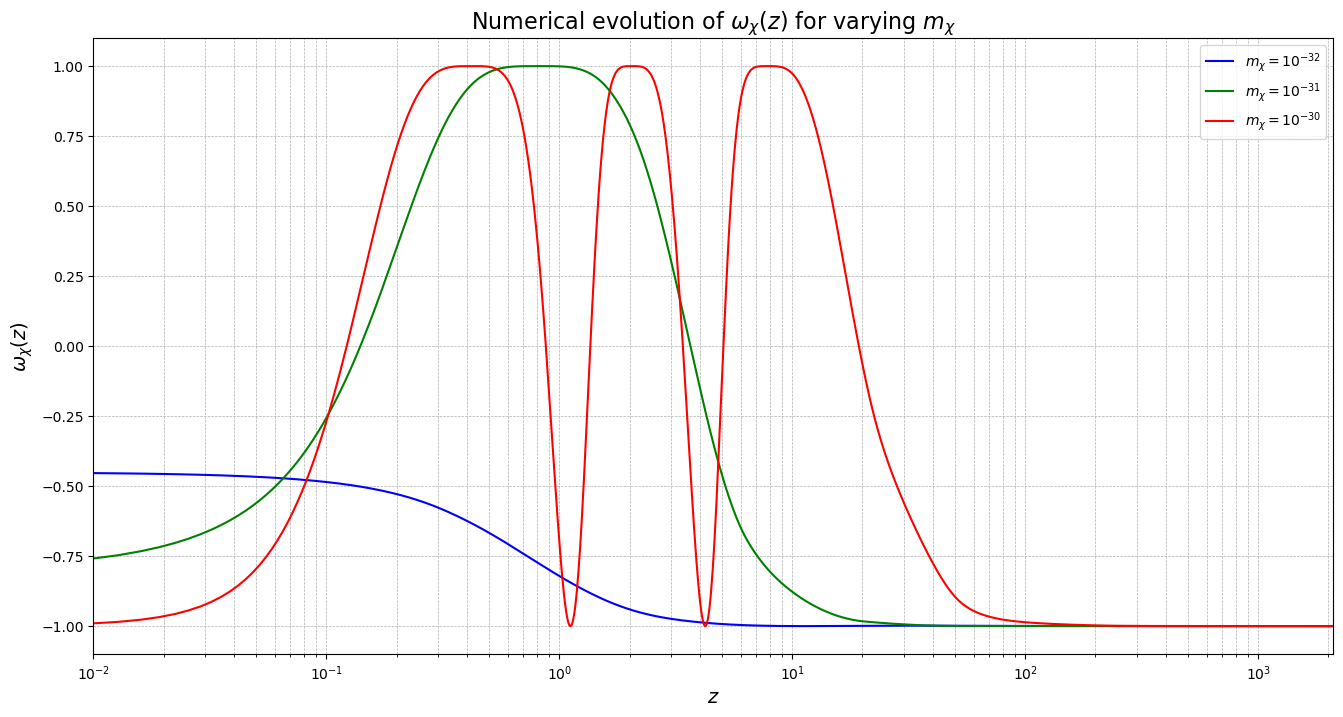

In [28]:
plt.figure(figsize=(16, 8))
plt.xscale('log')

mx_values=np.logspace(-32, -30, 3)
for mx, col in zip(mx_values, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (0, tau_fin), initial_conditions, args=(mx,), dense_output=True)
    vx_solution=solution.sol(tau_grid)[1]
    
    omega=(vx_solution**2-2*a_tau.sol(tau_grid)[0]**2*V(solution.sol(tau_grid)[0], mx))/(vx_solution**2+2*a_tau.sol(tau_grid)[0]**2*V(solution.sol(tau_grid)[0], mx))
    z_values=1./a_tau.sol(tau_grid)[0]-1.
    plt.plot(z_values, omega, color=col, label=rf'$m_\chi={LaTex_mass(mx)}$') 


plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 2100)
plt.ylabel(r'$\omega_\chi(z)$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Numerical evolution of $\omega_\chi(z)$ for varying $m_\chi$', fontsize=16)
plt.legend()
plt.show() 

In [29]:
rhocrit=3*mpl**2*H(a_tau.sol(tau_grid)[0])**2
Omega_M=(Omegam*a_tau.sol(tau_grid)[0]**(-3)*H0**2)/H(a_tau.sol(tau_grid)[0])**2
Omega_R=(Omegar*a_tau.sol(tau_grid)[0]**(-4)*H0**2)/H(a_tau.sol(tau_grid)[0])**2
Omega_L=(OmegaL*H0**2)/H(a_tau.sol(tau_grid)[0])**2

As a final step we can compute the density parameter $\Omega_\chi$ for different masses in the range we are interested $(10^{-27}\leq m_\chi \leq 10^{-32})$ and compare it with the known $\Omega_m$, $\Omega_r$ and $\Omega_\Lambda$.

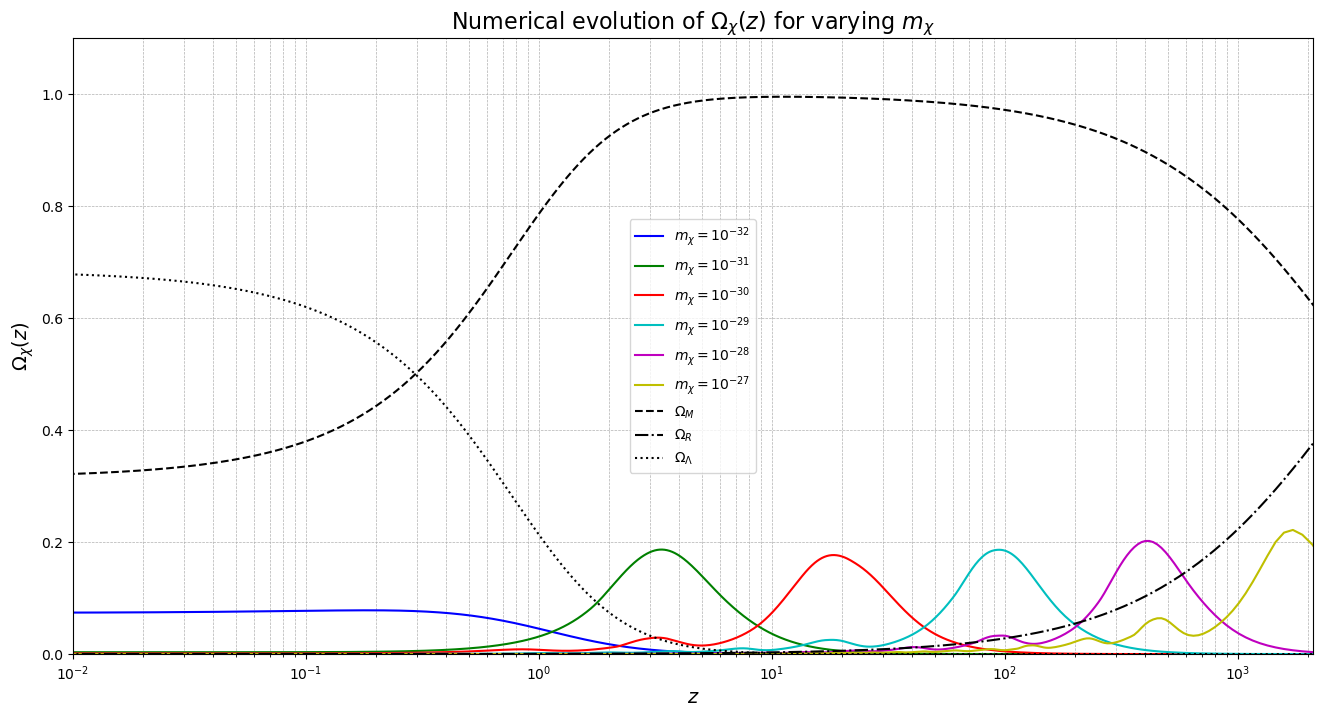

In [30]:
plt.figure(figsize=(16, 8))
plt.xscale('log')

mx_values=np.logspace(-32, -27, 6)
for mx, col in zip(mx_values, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (0, tau_fin), initial_conditions, args=(mx,), dense_output=True)
    vx_solution=solution.sol(tau_grid)[1]
    rhox=1/(2*a_tau.sol(tau_grid)[0]**2)*vx_solution**2+V(solution.sol(tau_grid)[0], mx)
    Omegax=rhox/rhocrit
    z_values=1./a_tau.sol(tau_grid)[0]-1.
    plt.plot(z_values, Omegax, color=col, label=rf'$m_\chi={LaTex_mass(mx)}$')

plt.plot(z_values, Omega_M, 'k--', label=r'$\Omega_M$')
plt.plot(z_values, Omega_R, 'k-.', label=r'$\Omega_R$')
plt.plot(z_values, Omega_L, 'k:', label=r'$\Omega_\Lambda$')

plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 2100)
plt.ylim(0, 1.1)
plt.ylabel(r'$\Omega_\chi(z)$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Numerical evolution of $\Omega_\chi(z)$ for varying $m_\chi$', fontsize=16)
plt.legend()
plt.show()

In this case the results are pretty similar to the paper.